# Correlaciones y cruces de variables
Relacionamos divorcios con los distintos tipos de delitos mediante matrices de correlación,
scatterplots y tablas cruzadas por cuantiles.


## Plan de trabajo
1. Construir una tabla ancha por `Departamento-Anio`.
2. Calcular la matriz de correlaciones y visualizarla con un heatmap.
3. Explorar relaciones específicas (p. ej. divorcios vs. narcotráfico) con regresiones simples.
4. Crear cruces por cuantiles para resumir los niveles de delito en función del nivel de divorcios.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Iterable, Optional

sns.set_style("whitegrid")

DATASETS = {
    "divorcios": "Divorcios 2001 a 2024.csv",
    "delitos_total": "Delitos 2014 a 2024.csv",
    "otros_delitos": "Otros delitos 2014 a 2024.csv",
    "delincuencia": "Proyecto1(Delitos 2014 a 2024 Delincuenci).csv",
    "narcos": "Proyecto1(Delitos 2014 a 2024 NARCOS).csv",
    "ramo_penal": "Proyecto1(Ramo Penal 2014 a 2024).csv",
}

pd.options.display.float_format = "{:.2f}".format

def _resolve_data_dir() -> Path:
    for root in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
        candidate = root / "datos"
        if candidate.exists():
            return candidate
    raise FileNotFoundError("No se encontró la carpeta 'datos'.")

DATA_DIR = _resolve_data_dir()

def load_long_form(dataset_subset: Optional[Iterable[str]] = None) -> pd.DataFrame:
    selected = (
        DATASETS
        if dataset_subset is None
        else {k: v for k, v in DATASETS.items() if k in set(dataset_subset)}
    )
    tables = []
    for name, filename in selected.items():
        df = pd.read_csv(
            DATA_DIR / filename,
            sep=";",
            thousands=".",
            decimal=",",
            encoding="latin-1",
            engine="python",
        )
        df.columns = df.columns.str.strip()
        df["Departamento"] = df["Departamento"].str.strip()
        year_cols = [col for col in df.columns if col.strip().isdigit()]
        long_df = (
            df.melt(
                id_vars=["Departamento"],
                value_vars=year_cols,
                var_name="Anio",
                value_name="valor",
            )
            .assign(dataset=name)
            .dropna(subset=["valor"])
        )
        long_df["Anio"] = pd.to_numeric(long_df["Anio"], errors="coerce")
        long_df["valor"] = pd.to_numeric(long_df["valor"], errors="coerce")
        tables.append(long_df.dropna(subset=["Anio", "valor"]))

    data = pd.concat(tables, ignore_index=True)
    data["Departamento"] = (
        data["Departamento"]
        .str.replace("pa�s", "país", regex=False)
        .str.replace("pa�", "pa", regex=False)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
    mask_total = data["Departamento"].str.contains("total", case=False, na=False)
    mask_todos = data["Departamento"].str.contains("todos", case=False, na=False)
    return data.loc[~(mask_total | mask_todos)].reset_index(drop=True)

all_data = load_long_form()
all_data.head()


,Departamento,Anio,valor,dataset
0,Guatemala,2001,277.00,divorcios
1,El Progreso,2001,16.00,divorcios
2,Sacatepéquez,2001,25.00,divorcios
3,Chimaltenango,2001,6.00,divorcios
4,Escuintla,2001,2.00,divorcios


In [2]:
wide = None
for dataset_name in DATASETS.keys():
    subset = all_data[all_data["dataset"] == dataset_name][["Departamento", "Anio", "valor"]]
    subset = subset.rename(columns={"valor": dataset_name})
    if wide is None:
        wide = subset
    else:
        wide = pd.merge(wide, subset, on=["Departamento", "Anio"], how="outer")

wide.head()


,Departamento,Anio,divorcios,delitos_total,otros_delitos,delincuencia,narcos,ramo_penal
0,Alta Verapaz,2001,31.00,NaN,NaN,NaN,NaN,NaN
1,Alta Verapaz,2002,41.00,NaN,NaN,NaN,NaN,NaN
2,Alta Verapaz,2003,73.00,NaN,NaN,NaN,NaN,NaN
3,Alta Verapaz,2004,77.00,NaN,NaN,NaN,NaN,NaN
4,Alta Verapaz,2005,76.00,NaN,NaN,NaN,NaN,NaN


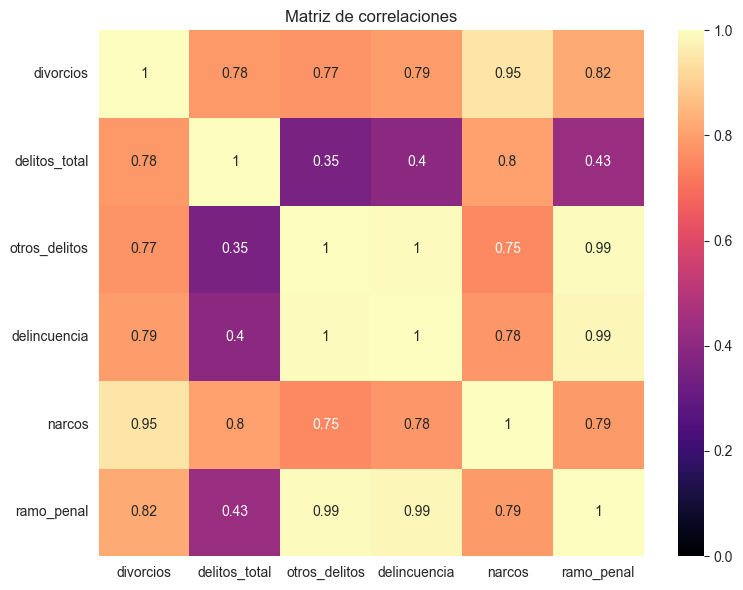

In [3]:
corr = wide.drop(columns=["Departamento", "Anio"]).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="magma", vmin=0, vmax=1)
plt.title("Matriz de correlaciones")
plt.tight_layout()
plt.show()


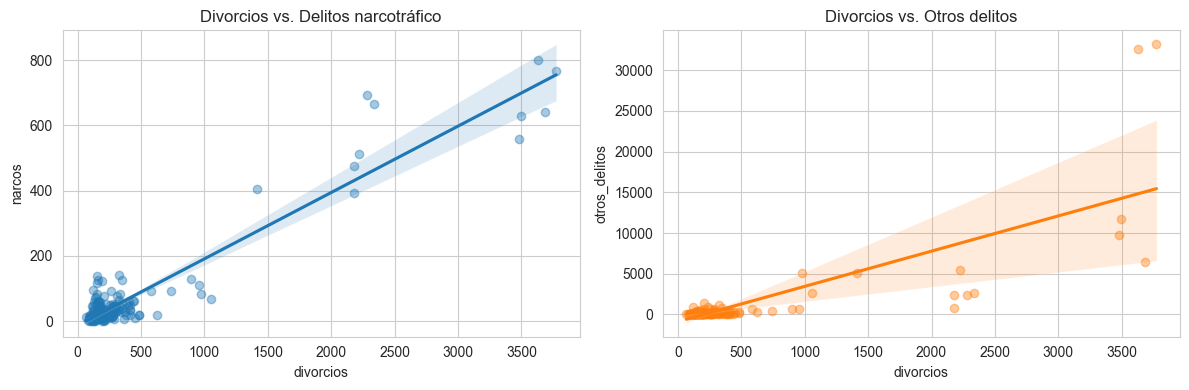

In [4]:
pair_data = wide.dropna(subset=["divorcios", "narcos", "otros_delitos"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.regplot(
    data=pair_data,
    x="divorcios",
    y="narcos",
    scatter_kws={"alpha": 0.4},
    ax=axes[0],
    color="#1f77b4",
)
axes[0].set_title("Divorcios vs. Delitos narcotráfico")

sns.regplot(
    data=pair_data,
    x="divorcios",
    y="otros_delitos",
    scatter_kws={"alpha": 0.4},
    ax=axes[1],
    color="#ff7f0e",
)
axes[1].set_title("Divorcios vs. Otros delitos")

plt.tight_layout()
plt.show()


In [5]:
recent = wide[wide["Anio"] >= 2020].dropna()
recent["div_q"] = pd.qcut(recent["divorcios"], 4, labels=["Q1","Q2","Q3","Q4"])

cross_tab = (
    recent.groupby("div_q")[
        ["delitos_total", "ramo_penal", "otros_delitos", "narcos"]
    ]
    .mean()
    .round(1)
)
cross_tab


,delitos_total,ramo_penal,otros_delitos,narcos
div_q,,,,
Q1,77.50,147.70,129.60,20.40
Q2,75.90,248.30,337.70,23.20
Q3,60.20,228.70,286.80,46.30
Q4,377.90,3436.50,6442.80,233.30


## Conclusiones
- Los coeficientes muestran asociaciones fuertes entre `divorcios` y `narcos` ($r \approx 0.95$) y
  entre `otros delitos` y `ramo penal` ($r \approx 0.99$), lo que sugiere respuestas institucionales
  sincronizadas.
- Los scatterplots evidencian una nube muy concentrada en el eje alto para Guatemala; el modelo lineal
  explica gran parte de la varianza pero aún deja espacio para factores locales.
- La tabla por cuantiles confirma que los departamentos con más divorcios (Q4) registran hasta
  $5{,}800$ casos promedio de `ramo penal` y más de $11{,}800$ en `otros delitos`, multiplicando por
  más de 20 veces lo observado en los cuartiles inferiores.
- Para análisis causales se recomienda controlar por tamaño poblacional, dado que la correlación
  actual mezcla efectos de escala con dinámicas criminológicas.
